# Procurement Data Foundation: Explore Before Ingest

This notebook demonstrates the exploration performed before implementing ingestion. It first inspects raw source structures and API payloads, then compares those observations with the project's production parsers and destination contracts.

The notebook is read-only with respect to project data and databases. It does not seed PostgreSQL, write files, or create embeddings. Live API examples are opt-in so the notebook remains reproducible offline. Public-source records and explicitly synthetic documents are always analyzed separately.

In [1]:
from collections import Counter
from dataclasses import asdict
from hashlib import sha256
from pathlib import Path
import os
import sys
import xml.etree.ElementTree as ET

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from pypdf import PdfReader


def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'uk-contracts.xml').is_file() and (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError('Open Jupyter from this repository or one of its subdirectories.')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ai_template_python.data_foundation.commodity_data import iter_pink_sheet_monthly
from ai_template_python.data_foundation.contracts_finder import iter_contracts_finder_notices
from ai_template_python.data_foundation.ingestion import (
    extract_document_text,
    load_document_manifest,
    world_bank_pdf_sources,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)
print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')

Project root: /home/rajesh/projects/Portfolio/enterprise-decision-intelligence
Data directory: /home/rajesh/projects/Portfolio/enterprise-decision-intelligence/data


## 1. Source inventory

Record formats, sizes, and hashes first. Hashes are used by ingestion for source-version and change detection; filenames alone are not sufficient provenance.

In [2]:
def file_sha256(path: Path) -> str:
    digest = sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

inventory = []
for path in sorted(DATA_DIR.rglob('*')):
    if path.is_file():
        inventory.append({
            'path': str(path.relative_to(PROJECT_ROOT)),
            'suffix': path.suffix.lower() or '[none]',
            'size_bytes': path.stat().st_size,
            'sha256': file_sha256(path),
        })
inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,path,suffix,size_bytes,sha256
0,data/CMO-Historical-Data-Annual.xlsx,.xlsx,3175465,d07bcb67ac39ceba4ef46a36e9d252f89d52c590ce6c05b23acb023d845e3a8b
1,data/CMO-Historical-Data-Monthly.xlsx,.xlsx,586099,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154
2,data/synthetic/documents/contract-s101.md,.md,830,779db1466dccedc90fb19114a21ccd2425fb00711bc0eb35d3e63c7eed1968cf
3,data/synthetic/documents/contract-s102.md,.md,926,83330da3ba32c31f465b191359c7192992d644f44bcf759064dda15e4f5a1fc5
4,data/synthetic/documents/contract-s103.md,.md,817,55a4d7f59235caa110da058d3f178736d70c68f7abc2d78904dff1919842c76e
5,data/synthetic/documents/contract-s104.md,.md,816,30d3c0a77fecf2baf640b8d3061e3c793f7f959b16f58f6ed4c381f59d7c8046
6,data/synthetic/documents/contract-s105.md,.md,826,4a5bcf58c978ed8354d776fcbb8eb9029ae9b13df73cd1c51aef9f865489d997
7,data/synthetic/documents/contract-s106.md,.md,848,5f9cc2c3a122ac322f46e8cb38e90c6464759814e8144dc67a371154db3df646
8,data/synthetic/documents/contract-s107.md,.md,842,75e207d9d06e3db154842c5561cbcd6bff0e835fa74112759a96c9f28910ac78
9,data/synthetic/documents/contract-s108.md,.md,809,44b2497c953045e456c222fb65eb6a87be03824df40e00b806a8248f40fe58d6


## Raw source inspection before normalization

Inspect a small structural sample from the original XML and workbook before using the production parser. This is where source-specific nulls, nested XML, status values, workbook header rows, and time keys become visible and influence the ingestion design.

In [3]:
contracts_path = DATA_DIR / 'uk-contracts.xml'
xml_root = ET.parse(contracts_path).getroot()
raw_notices = xml_root.findall('FullNotice')
raw_first_notice = raw_notices[0].find('Notice')
raw_fields = [
    {
        'field': child.tag,
        'has_nested_content': len(child) > 0,
        'sample': (child.text or '').strip()[:180] if len(child) == 0 else ET.tostring(child, encoding='unicode')[:180],
    }
    for child in raw_first_notice
    if child.tag != 'ContactDetails'
]
raw_status_counts = Counter(
    (node.findtext('Notice/Status') or '[missing]').strip()
    for node in raw_notices
)
print(f'Raw XML root: {xml_root.tag}; notice elements: {len(raw_notices):,}')
print(f'First raw notice ID: {raw_first_notice.findtext("Id")}')
print(f'Raw status values: {dict(raw_status_counts)}')
display(pd.DataFrame(raw_fields))

Raw XML root: ArrayOfFullNotice; notice elements: 1,000
First raw notice ID: 31525512-d1be-4ec3-9ecc-bd072f65c84c
Raw status values: {'Awarded': 944, 'Open': 56}


,field,has_nested_content,sample
0,Id,False,31525512-d1be-4ec3-9ecc-bd072f65c84c
1,ParentIdentifier,False,
2,Identifier,False,CF-0056700D8d000009sg5IEAQ
3,Title,False,Support services for Tableau Cloud
4,Description,False,Support services for Tableau Cloud
5,CpvDescription,False,"IT services: consulting, software development, Internet and support"
6,PublishedDate,False,2026-09-23T18:12:28+01:00
7,DeadlineDate,False,2026-08-27T12:00:00+01:00
8,ValueLow,False,20000
9,ValueHigh,False,40000


In [4]:
from openpyxl import load_workbook

monthly_workbook = DATA_DIR / 'CMO-Historical-Data-Monthly.xlsx'
workbook = load_workbook(monthly_workbook, read_only=True, data_only=True)
try:
    raw_sheet = workbook['Monthly Prices']
    raw_rows = list(raw_sheet.iter_rows(min_row=1, max_row=9, max_col=8, values_only=True))
    print(f'Workbook sheets: {workbook.sheetnames}')
    print(f'Monthly Prices dimensions: {raw_sheet.max_row:,} rows x {raw_sheet.max_column:,} columns')
    display(pd.DataFrame(raw_rows, columns=[f'column_{i}' for i in range(1, 9)]))
finally:
    workbook.close()

Workbook sheets: ['Mismatch Details', 'Monthly Prices', 'Monthly Indices', 'Description', 'Index Weights']
Monthly Prices dimensions: 807 rows x 89 columns


,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8
0,World Bank Commodity Price Data (The Pink Sheet),None,None,None,NaN,NaN,NaN,None
1,"monthly prices in nominal US dollars, 1960 to present",None,None,None,NaN,NaN,NaN,None
2,(monthly series are available only in nominal US dollars),None,None,None,NaN,NaN,NaN,None
3,"Updated on October 02, 2026",None,None,None,NaN,NaN,NaN,None
4,NaN,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African **","Natural gas, US"
5,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu)
6,1960M01,1.6,1.6,1.6,…,…,…,0.14
7,1960M02,1.6,1.6,1.6,…,…,…,0.14
8,1960M03,1.6,1.6,1.6,…,…,…,0.14


## 2. Contracts Finder XML

Parse with the streaming production parser. Public notices are not internal purchase orders: keep their source identity, status, GBP bounds, buyer, CPV description, and award records in the external-notice tables. Do not infer that a notice is awarded solely from the presence of a value.

In [5]:
contracts_path = DATA_DIR / 'uk-contracts.xml'
notices = list(iter_contracts_finder_notices(contracts_path))
notice_rows = [{
    'source_notice_id': item.source_notice_id,
    'identifier': item.identifier,
    'title': item.title,
    'description': item.description,
    'status': item.status,
    'organisation_name': item.organisation_name,
    'cpv_description': item.cpv_description,
    'notice_type': item.notice_type,
    'published_at': item.published_at,
    'deadline_at': item.deadline_at,
    'contract_start': item.contract_start,
    'contract_end': item.contract_end,
    'value_low_gbp': item.value_low_gbp,
    'value_high_gbp': item.value_high_gbp,
    'region': item.region,
    'postcode': item.postcode,
    'award_count': len(item.awards),
} for item in notices]
notices_df = pd.DataFrame(notice_rows)
notices_df['published_at'] = pd.to_datetime(notices_df['published_at'], utc=True, errors='coerce')
notices_df['deadline_at'] = pd.to_datetime(notices_df['deadline_at'], utc=True, errors='coerce')
notices_df['contract_start'] = pd.to_datetime(notices_df['contract_start'], utc=True, errors='coerce')
notices_df['contract_end'] = pd.to_datetime(notices_df['contract_end'], utc=True, errors='coerce')
print(f'Parsed {len(notices_df):,} notices; unique source IDs: {notices_df.source_notice_id.nunique():,}')
display(notices_df.head(8))

Parsed 1,000 notices; unique source IDs: 1,000


,source_notice_id,identifier,title,description,status,organisation_name,cpv_description,notice_type,published_at,deadline_at,contract_start,contract_end,value_low_gbp,value_high_gbp,region,postcode,award_count
0,31525512-d1be-4ec3-9ecc-bd072f65c84c,CF-0056700D8d000009sg5IEAQ,Support services for Tableau Cloud,Support services for Tableau Cloud,Awarded,Financial Conduct Authority,"IT services: consulting, software development, Internet and support",Contract,2026-09-23 17:12:28+00:00,2026-08-27 11:00:00+00:00,2026-09-03 23:00:00+00:00,2027-10-15 23:00:00+00:00,20000,40000,London,E20 1JN,1
1,3bd791cd-ffc0-47d5-b102-b4696e7ff73c,ITT for Project 10204144,ITT for Project 10204144,ITT for Project 10204144,Awarded,UK RESEARCH & INNOVATION,Project-supervision services other than for construction work,Contract,2026-09-23 17:02:14+00:00,2026-07-30 16:00:00+00:00,2026-08-31 23:00:00+00:00,2027-08-30 23:00:00+00:00,4980,None,United Kingdom,NaN,1
2,9e92dfc2-2954-4f18-b3b1-0a898e5d7180,ITT for Project 10205481,ITT for Project 10205481,ITT for Project 10205481,Awarded,UK RESEARCH & INNOVATION,Project-supervision services other than for construction work,Contract,2026-09-23 16:56:20+00:00,2026-07-30 16:00:00+00:00,2026-08-31 23:00:00+00:00,2027-08-30 23:00:00+00:00,3785,None,United Kingdom,NaN,1
3,acaeb3bc-9416-42c2-88af-6f420e23d0f0,CF-3697200D0O000000rwimUAA,Data Archive Maintenance Support,Lincolnshire Partnerships Foundation NHS Trust requires maintenance and support for an electroni...,Awarded,Lincolnshire Partnership NHS Foundation Trust,"IT services: consulting, software development, Internet and support",Contract,2026-09-23 16:53:02+00:00,2026-07-31 11:00:00+00:00,2026-08-31 23:00:00+00:00,2027-08-30 23:00:00+00:00,32412,138551.25,East Midlands,LN1 1FS,1
4,483298e1-c1b4-4f78-b505-853f8c316f08,IT-368-21086-QLS066 - AWARD,"QLS066 2026-09-23 (0900) Bury St Edmunds - Compass Community School Aylward Park: Meadow View, B...",Suffolk County Council is seeking a mini competition against the following Dynamic Purchasing Sy...,Awarded,Suffolk County Council Passenger Transport,Transport services (excl. Waste transport),Contract,2026-09-23 16:52:08+00:00,2026-09-23 08:00:00+00:00,2026-09-28 00:00:00+00:00,2027-07-31 00:00:00+00:00,0,0,Any region,IP1 2BX,1
5,ddfaea94-9199-49f6-b02a-f50799c2dba4,ITT for Projects 10199409 10202649,ITT for Projects 10199409 10202649,ITT for Projects 10199409 10202649,Awarded,UK RESEARCH & INNOVATION,Project-supervision services other than for construction work,Contract,2026-09-23 16:49:38+00:00,2026-07-30 16:00:00+00:00,2026-08-31 23:00:00+00:00,2027-08-30 23:00:00+00:00,6545,None,United Kingdom,NaN,1
6,c6b3fab6-002d-4c45-9a36-30b745610455,MT238131,2025-121 Qualitative Research Call-Off Contract,Ofgem's statutory role is to protect the interests of current and future energy consumers and to...,Awarded,Ofgem,Research services and Market research services and Research and development consultancy services,Contract,2026-09-23 16:45:12+00:00,2026-01-01 00:00:00+00:00,2026-08-19 23:00:00+00:00,2029-08-18 23:00:00+00:00,510000,None,Any region,NaN,1
7,d98a80c5-a261-4e1c-b372-deb3a9d0fd34,MT238118,2026-021 Econometrics and Economic Analysis,Ofgem is seeking a consultancy or consortium to act as a strategic analytical partner to provide...,Awarded,Ofgem,Business analysis consultancy services and Business and management consultancy and related servi...,Contract,2026-09-23 16:45:07+00:00,2026-01-01 00:00:00+00:00,2026-08-31 23:00:00+00:00,2030-03-31 00:00:00+00:00,3000000,None,Any region,NaN,1


In [6]:
notice_df_quality = pd.DataFrame({
    'check': [
        'duplicate source IDs',
        'missing titles',
        'missing status',
        'missing low value',
        'explicit zero low value',
        'missing buyer',
        'published after deadline (review; not auto-corrected)',
        'contract end before contract start (review; not auto-corrected)',
    ],
    'count': [
        int(notices_df.source_notice_id.duplicated().sum()),
        int(notices_df.title.isna().sum()),
        int(notices_df.status.isna().sum()),
        int(notices_df.value_low_gbp.isna().sum()),
        int((notices_df.value_low_gbp == 0).sum()),
        int(notices_df.organisation_name.isna().sum()),
        int((notices_df.published_at > notices_df.deadline_at).sum()),
        int((notices_df.contract_end < notices_df.contract_start).sum()),
    ],
})
display(notice_df_quality)
display(notices_df['status'].fillna('[missing]').value_counts().rename_axis('status').to_frame('notices'))
display((notices_df.isna().mean() * 100).sort_values(ascending=False).rename('missing_percent').to_frame().head(12))

,check,count
0,duplicate source IDs,0
1,missing titles,0
2,missing status,0
3,missing low value,4
4,explicit zero low value,130
5,missing buyer,0
6,published after deadline (review; not auto-corrected),927
7,contract end before contract start (review; not auto-corrected),0


,notices
status,
Awarded,944
Open,56


,missing_percent
postcode,62.7
value_high_gbp,60.5
region,7.1
value_low_gbp,0.4
contract_end,0.2
contract_start,0.2
source_notice_id,0.0
identifier,0.0
title,0.0
published_at,0.0


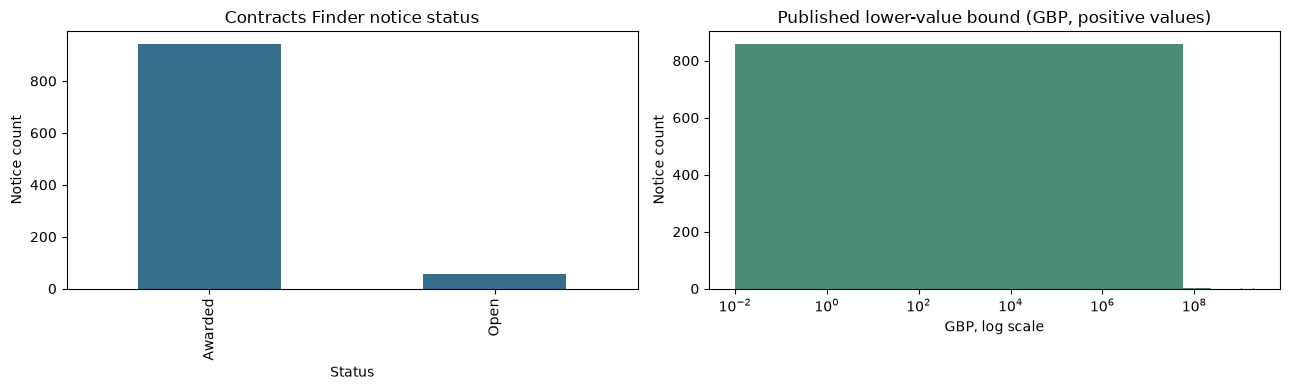

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
notices_df['status'].fillna('[missing]').value_counts().plot.bar(ax=axes[0], color='#376e8c')
axes[0].set_title('Contracts Finder notice status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Notice count')
low_values = pd.to_numeric(notices_df['value_low_gbp'], errors='coerce').dropna()
axes[1].hist(low_values[low_values > 0], bins=35, color='#4a8b73')
axes[1].set_xscale('log')
axes[1].set_title('Published lower-value bound (GBP, positive values)')
axes[1].set_xlabel('GBP, log scale')
axes[1].set_ylabel('Notice count')
plt.tight_layout()
plt.show()

In [8]:
award_rows = []
for notice in notices:
    for award in notice.awards:
        award_rows.append({
            'source_notice_id': notice.source_notice_id,
            'notice_title': notice.title,
            **asdict(award),
        })
awards_df = pd.DataFrame(award_rows)
if not awards_df.empty:
    awards_df['awarded_value_gbp'] = pd.to_numeric(awards_df['awarded_value_gbp'], errors='coerce')
    display(awards_df.head(10))
    display(awards_df[['supplier_name', 'awarded_value_gbp']].isna().mean().rename('missing_percent').to_frame())
else:
    display(Markdown('No award records were present in this export.'))

,source_notice_id,notice_title,award_id,supplier_name,supplier_reference,awarded_value_gbp,start_date,end_date,awarded_date
0,31525512-d1be-4ec3-9ecc-bd072f65c84c,Support services for Tableau Cloud,555829,SOFTCAT LTD - FCA,NaN,33806.59,2026-09-04 00:00:00+01:00,2027-10-16 00:00:00+01:00,2026-09-03 00:00:00+01:00
1,3bd791cd-ffc0-47d5-b102-b4696e7ff73c,ITT for Project 10204144,555828,SPINNOVATE LTD,14437525,4980.00,2026-09-01 00:00:00+01:00,2027-08-31 00:00:00+01:00,2026-08-13 00:00:00+01:00
2,9e92dfc2-2954-4f18-b3b1-0a898e5d7180,ITT for Project 10205481,555826,MOTION CONCEPTS LIMITED,9530535,3785.00,2026-09-01 00:00:00+01:00,2027-08-31 00:00:00+01:00,2026-08-10 00:00:00+01:00
3,acaeb3bc-9416-42c2-88af-6f420e23d0f0,Data Archive Maintenance Support,555825,STALIS LIMITED,NaN,138551.25,2026-09-01 00:00:00+01:00,2027-08-31 00:00:00+01:00,2026-09-11 00:00:00+01:00
4,483298e1-c1b4-4f78-b505-853f8c316f08,"QLS066 2026-09-23 (0900) Bury St Edmunds - Compass Community School Aylward Park: Meadow View, B...",555824,A2B Needham Market,NaN,26174.40,2026-09-28 00:00:00+01:00,2027-07-31 00:00:00+01:00,2026-09-23 00:00:00+01:00
5,ddfaea94-9199-49f6-b02a-f50799c2dba4,ITT for Projects 10199409 10202649,555822,SPARK ASSESSMENT SERVICES LIMITED,8275579,6545.00,2026-09-01 00:00:00+01:00,2027-08-31 00:00:00+01:00,2026-08-10 00:00:00+01:00
6,c6b3fab6-002d-4c45-9a36-30b745610455,2025-121 Qualitative Research Call-Off Contract,555821,Verian Group UK Ltd,13663077,510000.00,2026-08-20 00:00:00+01:00,2029-08-19 00:00:00+01:00,2026-08-14 00:00:00+01:00
7,d98a80c5-a261-4e1c-b372-deb3a9d0fd34,2026-021 Econometrics and Economic Analysis,555820,CEPA LLP,OC326074,3000000.00,2026-09-01 00:00:00+01:00,2030-03-31 00:00:00+00:00,2026-09-01 00:00:00+01:00
8,47e93d3f-fb97-47e4-bc94-8fa25e74fbe6,2026-026 Cost Allocation and Recovery Review Deliberative Research,555819,Thinks Insight & Strategy (Britain Thinks) Limited,07291125,193512.50,2026-08-28 00:00:00+01:00,2027-12-31 00:00:00+00:00,2026-08-28 00:00:00+01:00
9,9be72dad-fa8a-4f02-b4f1-06b3001831e7,ITT for Project 10205270,555817,Helix Projects Limited,15553567,5415.00,2026-09-01 00:00:00+01:00,2027-08-31 00:00:00+01:00,2026-08-11 00:00:00+01:00


,missing_percent
supplier_name,0.0
awarded_value_gbp,0.0


## 3. World Bank Pink Sheet workbooks

Inspect workbook tabs and headers before treating cells as observations. The monthly ingestion parser reads the `Monthly Prices` sheet, maps its header/unit rows, parses `YYYYMmm`, and skips nonnumeric placeholders instead of imputing them. Monthly prices are nominal USD series; they are not internal supplier costs.

In [9]:
from openpyxl import load_workbook

def workbook_overview(path: Path) -> pd.DataFrame:
    workbook = load_workbook(path, read_only=True, data_only=True)
    try:
        rows = []
        for name in workbook.sheetnames:
            sheet = workbook[name]
            preview = list(sheet.iter_rows(min_row=1, max_row=min(7, sheet.max_row), max_col=min(6, sheet.max_column), values_only=True))
            rows.append({'sheet': name, 'rows': sheet.max_row, 'columns': sheet.max_column, 'first_rows_preview': preview})
        return pd.DataFrame(rows)
    finally:
        workbook.close()

monthly_workbook = DATA_DIR / 'CMO-Historical-Data-Monthly.xlsx'
annual_workbook = DATA_DIR / 'CMO-Historical-Data-Annual.xlsx'
display(workbook_overview(monthly_workbook)[['sheet', 'rows', 'columns']])
display(workbook_overview(annual_workbook)[['sheet', 'rows', 'columns']])

,sheet,rows,columns
0,Mismatch Details,156,7
1,Monthly Prices,807,89
2,Monthly Indices,1362,81
3,Description,411,87
4,Index Weights,92,251


,sheet,rows,columns
0,Cover,13,2
1,Annual Prices (Nominal),248,87
2,Annual Indices (Nominal),65219,81
3,Annual Prices (Real),85,73
4,Annual Indices (Real),328,81
5,Description,409,87
6,Definitions,25,23
7,Index Weights,101,251


In [10]:
commodity_rows = list(iter_pink_sheet_monthly(monthly_workbook))
commodities_df = pd.DataFrame([asdict(row) for row in commodity_rows])
commodities_df['observed_on'] = pd.to_datetime(commodities_df['observed_on'])
commodities_df['value'] = pd.to_numeric(commodities_df['value'], errors='coerce')
print(f'{len(commodities_df):,} numeric observations across {commodities_df.series_id.nunique()} series')
print(f'Coverage: {commodities_df.observed_on.min():%Y-%m} through {commodities_df.observed_on.max():%Y-%m}')
display(commodities_df.groupby(['series_id', 'unit', 'currency'], dropna=False).agg(
    observations=('value', 'count'), first_month=('observed_on', 'min'), last_month=('observed_on', 'max'),
).sort_values('observations', ascending=False).head(20))
display(commodities_df.head())

50,451 numeric observations across 71 series
Coverage: 1960-01 through 2026-09


,,,observations,first_month,last_month
series_id,unit,currency,,,
aluminum,($/mt),USD,801,1960-01-01,2026-09-01
banana-us,($/kg),USD,801,1960-01-01,2026-09-01
beef,($/kg),USD,801,1960-01-01,2026-09-01
chicken,($/kg),USD,801,1960-01-01,2026-09-01
coffee-arabica,($/kg),USD,801,1960-01-01,2026-09-01
coconut-oil,($/mt),USD,801,1960-01-01,2026-09-01
cocoa,($/kg),USD,801,1960-01-01,2026-09-01
wheat-us-hrw,($/mt),USD,801,1960-01-01,2026-09-01
tin,($/mt),USD,801,1960-01-01,2026-09-01


,source_name,series_id,country_code,observed_on,value,unit,currency,source_url,retrieved_at,source_version
0,world_bank_pink_sheet,crude-oil-average,WLD,1960-01-01,1.60,($/bbl),USD,https://www.worldbank.org/en/research/commodity-markets,2026-10-03 09:21:25.749229+00:00,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154
1,world_bank_pink_sheet,crude-oil-brent,WLD,1960-01-01,1.60,($/bbl),USD,https://www.worldbank.org/en/research/commodity-markets,2026-10-03 09:21:25.749229+00:00,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154
2,world_bank_pink_sheet,crude-oil-dubai,WLD,1960-01-01,1.60,($/bbl),USD,https://www.worldbank.org/en/research/commodity-markets,2026-10-03 09:21:25.749229+00:00,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154
3,world_bank_pink_sheet,natural-gas-us,WLD,1960-01-01,0.14,($/mmbtu),USD,https://www.worldbank.org/en/research/commodity-markets,2026-10-03 09:21:25.749229+00:00,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154
4,world_bank_pink_sheet,natural-gas-europe,WLD,1960-01-01,0.40,($/mmbtu),USD,https://www.worldbank.org/en/research/commodity-markets,2026-10-03 09:21:25.749229+00:00,ea1c350827878ea3bbe30e3cda16a13fd3bd5b409b8458940dc94a36b5a33154


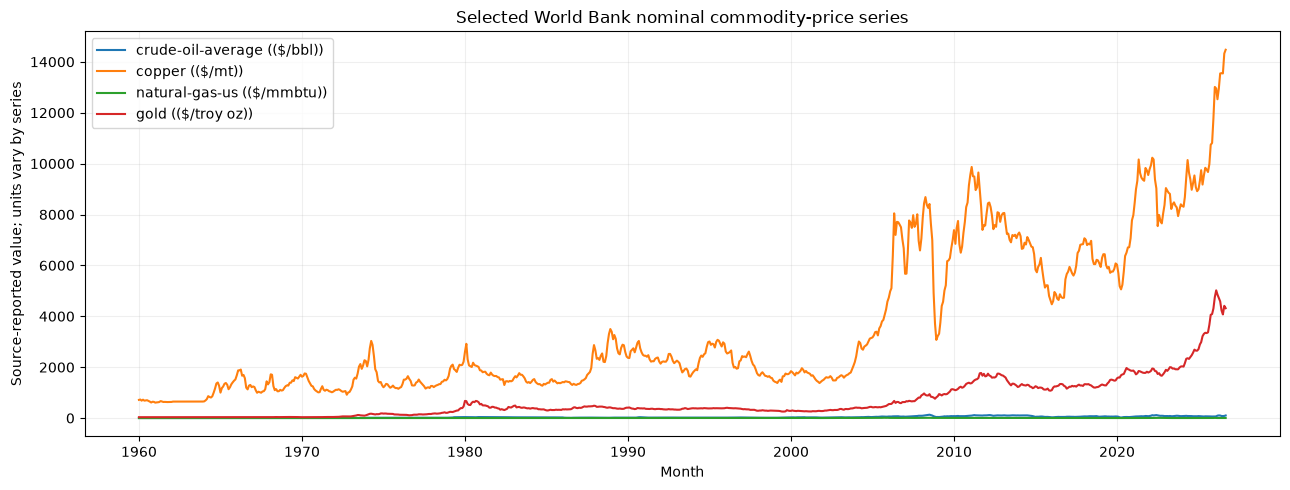

In [11]:
candidate_series = ['crude-oil-average', 'copper', 'natural-gas-us', 'gold']
available_series = [series for series in candidate_series if series in set(commodities_df.series_id)]
fig, ax = plt.subplots(figsize=(13, 5))
for series in available_series:
    series_rows = commodities_df.loc[commodities_df.series_id == series].sort_values('observed_on')
    ax.plot(series_rows['observed_on'], series_rows['value'], label=f'{series} ({series_rows.unit.iloc[0]})')
ax.set_title('Selected World Bank nominal commodity-price series')
ax.set_xlabel('Month')
ax.set_ylabel('Source-reported value; units vary by series')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The annual workbook is inspected for schema and frequency comparison but is not loaded by the default seed because it duplicates the Pink Sheet indicators at annual frequency. The monthly file reports nominal USD and contains blank/ellipsis cells; those are unavailable observations, not zero prices.

## 4. World Bank report PDFs

Check that the supplied reports are text-extractable before indexing. PDF extraction statistics are diagnostics only; the ingestion step still preserves the original PDF path and SHA-256 and indexes extracted page text with source metadata.

In [12]:
pdf_sources = world_bank_pdf_sources(DATA_DIR)
pdf_rows = []
for source in pdf_sources:
    extracted = extract_document_text(source.path)
    pdf_rows.append({
        'document_id': source.document_id,
        'title': source.title,
        'source_version_sha256': source.source_version,
        'extracted_characters': len(extracted),
        'page_count': len(PdfReader(source.path).pages),
    })
pdf_quality_df = pd.DataFrame(pdf_rows)
display(pdf_quality_df)

,document_id,title,source_version_sha256,extracted_characters,page_count
0,WB-COMMODITY-01,World Bank commodity price report 01,1b6bb6961c8a317dfe49afb49c2a0eaf83b5460fc4337fe70a1ecd291cfde2bd,20687,3
1,WB-COMMODITY-02,World Bank commodity price report 02,1b6bb6961c8a317dfe49afb49c2a0eaf83b5460fc4337fe70a1ecd291cfde2bd,20687,3
2,WB-COMMODITY-03,World Bank commodity price report 03,22a6541f44783328f82f100f08620715541365fc4575870eeaf264346d7e1a07,56671,13
3,WB-COMMODITY-04,World Bank commodity price report 04,472af3c6b02ff8df2e93dcddf09f4ee011a869cffbc1403abda221637967c22c,244387,69
4,WB-COMMODITY-05,World Bank commodity price report 05,0517bf7a495d0f8c91edda0b3d6f6b43a131efa73be06a4c5db73b5389f8875d,5380,2


## 5. Synthetic reference documents

These documents are fictional test evidence, not source evidence about real suppliers. The ingestion manifest validates every file hash and labels each document as synthetic before it reaches PostgreSQL or Qdrant.

In [13]:
manifest_path = DATA_DIR / 'synthetic' / 'documents' / 'manifest.json'
if manifest_path.is_file():
    document_sources = load_document_manifest(manifest_path)
    documents_df = pd.DataFrame([{
        'document_id': source.document_id,
        'document_type': source.document_type,
        'title': source.title,
        'supplier_id': source.supplier_id,
        'effective_from': source.effective_from,
        'effective_to': source.effective_to,
        'is_synthetic': source.is_synthetic,
        'sha256': source.content_sha256,
    } for source in document_sources])
    display(documents_df.groupby(['document_type', 'is_synthetic']).size().rename('documents').to_frame())
    display(documents_df.head(10))
    example_contract = next(source for source in document_sources if source.document_type == 'contract' and source.supplier_id == 'S102')
    display(Markdown(extract_document_text(example_contract.path)))
else:
    document_sources = []
    display(Markdown('No generated-document manifest found. Run the documented `generate-documents` command before indexing synthetic documents.'))

,,documents
document_type,is_synthetic,
contract,True,8
policy,True,2
supplier_profile,True,8


,document_id,document_type,title,supplier_id,effective_from,effective_to,is_synthetic,sha256
0,SYN-DOC-CON-S101,contract,Fictional Northstar Components Ltd supply agreement,S101,2024-01-01,2026-06-30,True,779db1466dccedc90fb19114a21ccd2425fb00711bc0eb35d3e63c7eed1968cf
1,SYN-DOC-PROFILE-S101,supplier_profile,Supplier profile: Fictional Northstar Components Ltd,S101,2024-01-01,2025-12-31,True,41f3d2518fc40eaca003222c62afd352321bb30a9b12f7338d8db9f16bfc5f8e
2,SYN-DOC-CON-S102,contract,Fictional Meridian Industrial Supply Ltd supply agreement,S102,2024-01-01,2026-06-30,True,83330da3ba32c31f465b191359c7192992d644f44bcf759064dda15e4f5a1fc5
3,SYN-DOC-PROFILE-S102,supplier_profile,Supplier profile: Fictional Meridian Industrial Supply Ltd,S102,2024-01-01,2025-12-31,True,b2a915527f8a5d977951816278c9d1b1f67b851583cb049c97207af986bb49a5
4,SYN-DOC-CON-S103,contract,Fictional Alder Materials Group Ltd supply agreement,S103,2024-01-01,2026-06-30,True,55a4d7f59235caa110da058d3f178736d70c68f7abc2d78904dff1919842c76e
5,SYN-DOC-PROFILE-S103,supplier_profile,Supplier profile: Fictional Alder Materials Group Ltd,S103,2024-01-01,2025-12-31,True,819da1d51a8b45db4e3f1010d0eed21638c38e9c30d34edc32a7dc2371baf84a
6,SYN-DOC-CON-S104,contract,Fictional Brookline Packaging Ltd supply agreement,S104,2024-01-01,2026-06-30,True,30d3c0a77fecf2baf640b8d3061e3c793f7f959b16f58f6ed4c381f59d7c8046
7,SYN-DOC-PROFILE-S104,supplier_profile,Supplier profile: Fictional Brookline Packaging Ltd,S104,2024-01-01,2025-12-31,True,ba693a8c3d7177d3cfc2fd1873fea77ee47848f072f5d7ad75cf10631900ba28
8,SYN-DOC-CON-S105,contract,Fictional Cairn Logistics Services Ltd supply agreement,S105,2024-01-01,2026-06-30,True,4a5bcf58c978ed8354d776fcbb8eb9029ae9b13df73cd1c51aef9f865489d997
9,SYN-DOC-PROFILE-S105,supplier_profile,Supplier profile: Fictional Cairn Logistics Services Ltd,S105,2024-01-01,2025-12-31,True,4d407d8d959c14b1509aac15eb35811bfda0b1d3c8ecc7f9085090296f57b856


> SYNTHETIC PORTFOLIO DATA. This fictional document is generated for local testing.

# Fictional Meridian Industrial Supply Ltd supply agreement

## Parties and term

Buyer: Example Procurement Group (fictional). Supplier: Fictional Meridian Industrial Supply Ltd.
Contract reference: SYN-CON-S102. Effective 2024-01-01 through 2026-06-30.
Category: industrial-components. All stated amounts are GBP.

## Pricing and adjustment

Annual reference value: GBP 138,500.00. A documented annual adjustment may not exceed 5% and requires buyer approval. Any request above the cap requires a written cost breakdown and an executed amendment.
Invoices must reference an approved purchase order. Disputed price changes do not
automatically amend existing purchase orders.

## Delivery and records

The supplier reports monthly delivery and quality metrics. Both parties retain
purchase-order, invoice, and adjustment records for audit.


## 6. Ingestion handoff

This matrix is the boundary between raw source inspection and ingestion. It records what should be persisted, how source identity is preserved, and which findings require review rather than silent cleanup. No rows or documents are changed by this notebook.

In [14]:
handoff_df = pd.DataFrame([
    {'source': 'Contracts Finder XML', 'records': len(notices_df), 'destination': 'contracts_finder_notices + contracts_finder_awards', 'key': 'Contracts Finder notice/award ID', 'review': 'Keep Open/Awarded status, GBP bounds, nils, timezone-aware timestamps, and source file hash; omit ContactDetails.'},
    {'source': 'World Bank Pink Sheet monthly workbook', 'records': len(commodities_df), 'destination': 'commodity_observations', 'key': 'source + series + WLD + observation month', 'review': 'Keep reported unit/currency and workbook hash; do not impute blanks or combine annual/monthly frequencies.'},
    {'source': 'World Bank commodity PDFs', 'records': len(pdf_quality_df), 'destination': 'source_documents + market_reports Qdrant collection', 'key': 'stable document ID + PDF SHA-256', 'review': 'Confirm extracted text is useful; preserve PDF page locators and source URL.'},
    {'source': 'Generated procurement documents', 'records': len(document_sources), 'destination': 'source_documents + typed Qdrant collection', 'key': 'manifest document ID + content SHA-256', 'review': 'Retain explicit synthetic labels and effective dates; never present as real supplier evidence.'},
])
display(handoff_df)

,source,records,destination,key,review
0,Contracts Finder XML,1000,contracts_finder_notices + contracts_finder_awards,Contracts Finder notice/award ID,"Keep Open/Awarded status, GBP bounds, nils, timezone-aware timestamps, and source file hash; omi..."
1,World Bank Pink Sheet monthly workbook,50451,commodity_observations,source + series + WLD + observation month,Keep reported unit/currency and workbook hash; do not impute blanks or combine annual/monthly fr...
2,World Bank commodity PDFs,5,source_documents + market_reports Qdrant collection,stable document ID + PDF SHA-256,Confirm extracted text is useful; preserve PDF page locators and source URL.
3,Generated procurement documents,18,source_documents + typed Qdrant collection,manifest document ID + content SHA-256,Retain explicit synthetic labels and effective dates; never present as real supplier evidence.


## Interpretation notes

- Notice values are publication estimates/bounds, not internal spend transactions.
- Pink Sheet series have different units and start dates; compare each series only with its own unit and an economically appropriate category.
- Missing, zero, and suppressed values are distinct states. This notebook reports them and leaves remediation to an explicit ingestion policy.
- Synthetic S102 exists only to exercise an investigation workflow; no inference about the public Contracts Finder records should be drawn from it.
- Live World Bank/FRED/USAspending/SEC/Contracts Finder API calls and Gemini embeddings happen in adapters/ingestion commands, not in this EDA notebook.

## Optional live API samples

These cells inspect raw API responses before an adapter normalizes them. They are read-only and disabled by default so **Run All** remains deterministic and works offline. Set `RUN_LIVE_API_SAMPLES = True` in the next cell, then run only the provider cell you want to inspect. FRED requires `FRED_API_KEY`; SEC requires a real contact `SEC_USER_AGENT`.

In [15]:
RUN_LIVE_API_SAMPLES = True
API_TIMEOUT = httpx.Timeout(20.0, connect=5.0)
print('Live API calls enabled:', RUN_LIVE_API_SAMPLES)

Live API calls enabled: True


In [16]:
if RUN_LIVE_API_SAMPLES:
    response = httpx.get(
        'https://api.worldbank.org/v2/country/GBR/indicator/FP.CPI.TOTL.ZG',
        params={'format': 'json', 'date': '2020:2024', 'per_page': 10},
        timeout=API_TIMEOUT,
    )
    response.raise_for_status()
    wb_metadata, wb_rows = response.json()
    print('World Bank response metadata:', wb_metadata)
    display(pd.DataFrame(wb_rows or []).head())
else:
    print('Skipped. Set RUN_LIVE_API_SAMPLES=True and rerun this cell to request public World Bank CPI data.')

World Bank response metadata: {'page': 1, 'pages': 1, 'per_page': 10, 'total': 5, 'sourceid': '2', 'lastupdated': '2026-07-13'}


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, consumer prices (annual %)'}","{'id': 'GB', 'value': 'United Kingdom'}",GBR,2024,3.271573,,,1
1,"{'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, consumer prices (annual %)'}","{'id': 'GB', 'value': 'United Kingdom'}",GBR,2023,6.793967,,,1
2,"{'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, consumer prices (annual %)'}","{'id': 'GB', 'value': 'United Kingdom'}",GBR,2022,7.922049,,,1
3,"{'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, consumer prices (annual %)'}","{'id': 'GB', 'value': 'United Kingdom'}",GBR,2021,2.518371,,,1
4,"{'id': 'FP.CPI.TOTL.ZG', 'value': 'Inflation, consumer prices (annual %)'}","{'id': 'GB', 'value': 'United Kingdom'}",GBR,2020,0.989487,,,1


In [17]:
fred_api_key = os.environ.get('FRED_API_KEY', '')
if RUN_LIVE_API_SAMPLES and fred_api_key:
    response = httpx.get(
        'https://api.stlouisfed.org/fred/series/observations',
        params={
            'series_id': 'CPIAUCSL',
            'api_key': fred_api_key,
            'file_type': 'json',
            'observation_start': '2020-01-01',
            'observation_end': '2024-12-31',
            'limit': 10,
            'sort_order': 'asc',
        },
        timeout=API_TIMEOUT,
    )
    response.raise_for_status()
    fred_payload = response.json()
    print({key: value for key, value in fred_payload.items() if key != 'observations'})
    display(pd.DataFrame(fred_payload.get('observations', [])).head())
elif RUN_LIVE_API_SAMPLES:
    print('Skipped: set FRED_API_KEY in the notebook environment; the key is never displayed.')
else:
    print('Skipped. Enable RUN_LIVE_API_SAMPLES and configure FRED_API_KEY to inspect FRED observations.')

{'realtime_start': '2026-10-03', 'realtime_end': '2026-10-03', 'observation_start': '2020-01-01', 'observation_end': '2024-12-31', 'units': 'lin', 'output_type': 1, 'file_type': 'json', 'order_by': 'observation_date', 'sort_order': 'asc', 'count': 60, 'offset': 0, 'limit': 10}


,realtime_start,realtime_end,date,value
0,2026-10-03,2026-10-03,2020-01-01,259.127
1,2026-10-03,2026-10-03,2020-02-01,259.250
2,2026-10-03,2026-10-03,2020-03-01,258.076
3,2026-10-03,2026-10-03,2020-04-01,256.032
4,2026-10-03,2026-10-03,2020-05-01,255.802


In [18]:
if RUN_LIVE_API_SAMPLES:
    usaspending_payload = {
        'filters': {
            'time_period': [{'start_date': '2024-01-01', 'end_date': '2024-12-31'}],
            'award_type_codes': ['A', 'B', 'C', 'D'],
        },
        'fields': ['Award ID', 'Recipient Name', 'Award Amount', 'Start Date', 'End Date', 'Awarding Agency', 'Award Type'],
        'page': 1,
        'limit': 10,
        'sort': 'Award Amount',
        'order': 'desc',
    }
    response = httpx.post(
        'https://api.usaspending.gov/api/v2/search/spending_by_award/',
        json=usaspending_payload,
        timeout=API_TIMEOUT,
    )
    response.raise_for_status()
    usaspending_result = response.json()
    print('USAspending response keys:', list(usaspending_result))
    display(pd.DataFrame(usaspending_result.get('results', [])).head())
else:
    print('Skipped. Set RUN_LIVE_API_SAMPLES=True to inspect public USAspending award search results.')

USAspending response keys: ['spending_level', 'limit', 'results', 'page_metadata', 'messages']


,internal_id,Award ID,Recipient Name,Award Amount,Start Date,End Date,Awarding Agency,Award Type,awarding_agency_id,agency_slug,generated_internal_id
0,307885715,HT940216C0001,HUMANA GOVERNMENT BUSINESS INC,5.126921e+10,2016-08-01,2025-12-31,Department of Defense,None,1173,department-of-defense,CONT_AWD_HT940216C0001_9700_-NONE-_-NONE-
1,295476065,DEAC0494AL85000,LOCKHEED MARTIN CORP,4.806374e+10,1993-10-15,2017-04-30,Department of Energy,None,930,department-of-energy,CONT_AWD_DEAC0494AL85000_8900_-NONE-_-NONE-
2,295527116,DENA0003525,"NATIONAL TECHNOLOGY & ENGINEERING SOLUTIONS OF SANDIA, LLC",4.346068e+10,2017-01-18,2027-04-30,Department of Energy,None,930,department-of-energy,CONT_AWD_DENA0003525_8900_-NONE-_-NONE-
3,295476106,DEAC0500OR22725,UT-BATTELLE LLC,4.266857e+10,1999-10-15,2030-03-31,Department of Energy,None,930,department-of-energy,CONT_AWD_DEAC0500OR22725_8900_-NONE-_-NONE-
4,295477233,DEAC5207NA27344,"LAWRENCE LIVERMORE NATIONAL SECURITY, LLC",4.160703e+10,2007-05-09,2031-09-30,Department of Energy,None,930,department-of-energy,CONT_AWD_DEAC5207NA27344_8900_-NONE-_-NONE-


In [19]:
sec_user_agent = os.environ.get('SEC_USER_AGENT', '').strip()
if RUN_LIVE_API_SAMPLES and sec_user_agent and '@' in sec_user_agent:
    response = httpx.get(
        'https://data.sec.gov/api/xbrl/companyfacts/CIK0000320193.json',
        headers={'User-Agent': sec_user_agent, 'Accept-Encoding': 'gzip, deflate'},
        timeout=API_TIMEOUT,
    )
    response.raise_for_status()
    sec_facts = response.json()
    print('SEC entity:', sec_facts.get('entityName'))
    print('Taxonomies:', list(sec_facts.get('facts', {})))
    us_gaap = sec_facts.get('facts', {}).get('us-gaap', {})
    display(pd.DataFrame([
        {'concept': key, 'label': value.get('label')}
        for key, value in list(us_gaap.items())[:20]
    ]))
elif RUN_LIVE_API_SAMPLES:
    print('Skipped: configure SEC_USER_AGENT with an application name and contact email.')
else:
    print('Skipped. Enable RUN_LIVE_API_SAMPLES and configure SEC_USER_AGENT to inspect SEC company facts.')

SEC entity: Apple Inc.
Taxonomies: ['dei', 'us-gaap']


,concept,label
0,AccountsPayable,Accounts Payable (Deprecated 2009-01-31)
1,AccountsPayableCurrent,"Accounts Payable, Current"
2,AccountsReceivableNetCurrent,"Accounts Receivable, after Allowance for Credit Loss, Current"
3,AccruedIncomeTaxesCurrent,"Accrued Income Taxes, Current"
4,AccruedIncomeTaxesNoncurrent,"Accrued Income Taxes, Noncurrent"
5,AccruedLiabilities,Accrued Liabilities (Deprecated 2009-01-31)
6,AccruedLiabilitiesCurrent,"Accrued Liabilities, Current"
7,AccruedMarketingCostsCurrent,"Accrued Marketing Costs, Current"
8,AccumulatedDepreciationDepletionAndAmortizationPropertyPlantAndEquipment,"Accumulated Depreciation, Depletion and Amortization, Property, Plant, and Equipment"
9,AccumulatedOtherComprehensiveIncomeLossAvailableForSaleSecuritiesAdjustmentNetOfTax,"AOCI, Debt Securities, Available-for-sale, Adjustment, after Tax"


In [20]:
if RUN_LIVE_API_SAMPLES:
    response = httpx.get(
        'https://www.contractsfinder.service.gov.uk/Published/Notices/OCDS/Search',
        params={
            'publishedFrom': '2025-01-01',
            'publishedTo': '2025-01-31',
            'limit': 5,
        },
        headers={'Accept': 'application/json'},
        timeout=API_TIMEOUT,
    )
    response.raise_for_status()
    ocds_package = response.json()
    releases = ocds_package.get('releases', [])
    print('OCDS package keys:', list(ocds_package))
    display(pd.DataFrame([
        {
            'release_id': release.get('id'),
            'ocid': release.get('ocid'),
            'date': release.get('date'),
            'tag': ', '.join(release.get('tag', [])),
        }
        for release in releases
    ]))
else:
    print('Skipped. Set RUN_LIVE_API_SAMPLES=True to inspect published Contracts Finder OCDS releases.')

OCDS package keys: ['uri', 'version', 'extensions', 'publishedDate', 'publisher', 'license', 'publicationPolicy', 'releases', 'links']


,release_id,ocid,date,tag
0,4a0c73c3-6b7a-4d5d-b29b-3b10e0c97356-822004,ocds-b5fd17-eeea3d67-ec72-46d1-b155-752617037195,2025-01-30T22:42:58Z,award
1,5fa764e9-88ed-45d7-b7c9-5e5ad45ad72a-822003,ocds-b5fd17-18bc5ff6-4a81-4e57-afe0-291bdf1ad87c,2025-01-30T22:08:44Z,award
2,c5857b54-d9a1-4ec5-ac43-b7eda4507a96-822002,ocds-b5fd17-4edbfa48-553f-4e39-8225-c4e345376242,2025-01-30T21:13:04Z,award
3,3ac9f8d3-0edb-414d-81ad-445c50d2b47e-822001,ocds-b5fd17-0f0948c5-07a2-44f5-b231-d76d00f6a373,2025-01-30T20:43:12Z,tender
4,54a29b74-6aa6-4c4e-9f28-adbaf2b4ce36-822000,ocds-b5fd17-1f40d054-1c93-445d-b7c0-018fdc9da523,2025-01-30T20:06:12Z,tender


## Findings

- The Contracts Finder export has **1,000 notices**: 944 awarded and 56 open, with no duplicate IDs or missing titles/statuses. Four low-value bounds are missing; 130 are explicitly zero. High-value bounds and postcodes are often absent. The 927 publication-after-deadline pairs need notice-type/date-semantic review before time-based analysis.
- The Pink Sheet contains **50,451 observations across 71 series**, covering January 1960 to September 2026. Units vary by series, so compare like-for-like series and retain source units; do not impute blank cells.
- All **five World Bank PDFs** have extractable text, but reports 01 and 02 share the same file hash and should be deduplicated before indexing.
- The **18 generated documents** are all explicitly synthetic: eight contracts, eight supplier profiles, and two policies. Keep them separate from public source evidence.